In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r'C:\Users\SHYAM SASHANK\OneDrive\Desktop\Data_Science\Assginment_CSV\delivery_time.csv')

In [3]:
df.head()

,Delivery Time,Sorting Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10


In [4]:
X=np.array(df["Sorting Time"])
X

array([10,  4,  6,  9, 10,  6,  7,  3, 10,  9,  8,  4,  7,  3,  3,  4,  6,
        7,  2,  7,  5], dtype=int64)

In [5]:
X = np.array(X).reshape(-1,1)
X.shape

(21, 1)

In [6]:
y=df["Delivery Time"]
y

0     21.00
1     13.50
2     19.75
3     24.00
4     29.00
5     15.35
6     19.00
7      9.50
8     17.90
9     18.75
10    19.83
11    10.75
12    16.68
13    11.50
14    12.03
15    14.88
16    13.75
17    18.11
18     8.00
19    17.83
20    21.50
Name: Delivery Time, dtype: float64

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
lm=LinearRegression()

In [9]:
lm.fit(X,y)

LinearRegression()

In [10]:
lm.coef_

array([1.6490199])

In [11]:
lm.intercept_

6.58273397199706

In [12]:
lm.predict([[10]])

array([23.07293294])

In [13]:
a=10*1.6490199+6.58273397199706
a

23.072932971997062

In [14]:
#Method2

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train,X_test,Y_train,Y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [17]:
X_train

array([[ 8],
       [ 3],
       [ 2],
       [ 7],
       [ 7],
       [10],
       [ 6],
       [ 6],
       [ 6],
       [ 9],
       [ 3],
       [ 7],
       [ 9],
       [10],
       [ 4],
       [ 7]], dtype=int64)

In [18]:
X_test

array([[10],
       [ 3],
       [ 5],
       [ 4],
       [ 4]], dtype=int64)

In [19]:
Y_train

10    19.83
14    12.03
18     8.00
6     19.00
19    17.83
4     29.00
2     19.75
5     15.35
16    13.75
9     18.75
7      9.50
17    18.11
3     24.00
0     21.00
15    14.88
12    16.68
Name: Delivery Time, dtype: float64

In [20]:
Y_test

8     17.90
13    11.50
20    21.50
1     13.50
11    10.75
Name: Delivery Time, dtype: float64

In [21]:
lm.fit(X_train,Y_train)

LinearRegression()

In [22]:
y_predict_train=lm.predict(X_train)
y_predict_train

array([20.18554348, 10.70456522,  8.80836957, 18.28934783, 18.28934783,
       23.97793478, 16.39315217, 16.39315217, 16.39315217, 22.08173913,
       10.70456522, 18.28934783, 22.08173913, 23.97793478, 12.60076087,
       18.28934783])

In [23]:
y_predict_test=lm.predict(X_test)
y_predict_test

array([23.97793478, 10.70456522, 14.49695652, 12.60076087, 12.60076087])

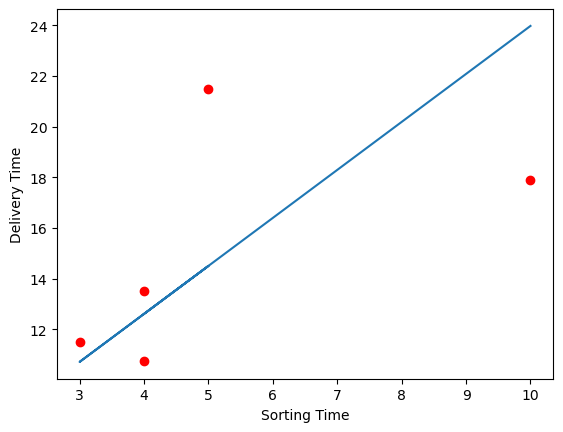

In [24]:
plt.scatter(X_test,Y_test,color="red")
plt.plot(X_test,y_predict_test)
plt.xlabel("Sorting Time")
plt.ylabel("Delivery Time")
plt.show()

In [25]:
from sklearn.metrics import r2_score
score = r2_score(Y_train,y_predict_train)
print("The accuracy of our model is {}%".format(round(score, 2) *100))

The accuracy of our model is 80.0%


In [26]:
from sklearn.metrics import mean_squared_error
import numpy as np
score = np.sqrt(mean_squared_error(Y_test,y_predict_test))
print("The Mean Squared Error of our Model is {}".format(round(score, 2)))

The Mean Squared Error of our Model is 4.26


In [27]:
import statsmodels.formula.api as smf

In [28]:
model=smf.ols('y~X',data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     40.80
Date:                Wed, 23 Aug 2023   Prob (F-statistic):           3.98e-06
Time:                        14:24:23   Log-Likelihood:                -51.357
No. Observations:                  21   AIC:                             106.7
Df Residuals:                      19   BIC:                             108.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.5827      1.722      3.823      0.001       2.979      10.186
X              1.6490      0.258      6.387      0.000       1.109       2.189
==============================================================================
Omnibus:                        3.649   Durbin-Watson:                   1.248
Prob(Omnibus):                  0.161   Jarque-Bera (JB):                2.086
Skew:                           0.750   Prob(JB):                        0.352
Kurtosis:                       3.367   Cond. No.                         18.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Using Log Function

In [29]:
y

0     21.00
1     13.50
2     19.75
3     24.00
4     29.00
5     15.35
6     19.00
7      9.50
8     17.90
9     18.75
10    19.83
11    10.75
12    16.68
13    11.50
14    12.03
15    14.88
16    13.75
17    18.11
18     8.00
19    17.83
20    21.50
Name: Delivery Time, dtype: float64

In [30]:
df["Log_Delivery"]=np.log2(df["Delivery Time"])
df

,Delivery Time,Sorting Time,Log_Delivery
0,21.00,10,4.392317
1,13.50,4,3.754888
2,19.75,6,4.303781
3,24.00,9,4.584963
4,29.00,10,4.857981
5,15.35,6,3.940167
6,19.00,7,4.247928
7,9.50,3,3.247928
8,17.90,10,4.161888
9,18.75,9,4.228819


In [31]:
y1=df["Log_Delivery"]

In [32]:
x_train,x_test,y_train,y_test=train_test_split(X,y1, random_state=2, test_size=0.3)

In [33]:
x_train

array([[ 2],
       [10],
       [ 6],
       [ 4],
       [ 7],
       [ 3],
       [ 7],
       [ 6],
       [ 6],
       [ 4],
       [ 5],
       [ 3],
       [ 4],
       [10]], dtype=int64)

In [34]:
x_test

array([[ 8],
       [ 7],
       [10],
       [ 3],
       [ 9],
       [ 9],
       [ 7]], dtype=int64)

In [35]:
y_train

18    3.000000
4     4.857981
5     3.940167
1     3.754888
19    4.156235
7     3.247928
17    4.178715
16    3.781360
2     4.303781
11    3.426265
20    4.426265
13    3.523562
15    3.895303
8     4.161888
Name: Log_Delivery, dtype: float64

In [36]:
y_test

10    4.309613
6     4.247928
0     4.392317
14    3.588565
3     4.584963
9     4.228819
12    4.060047
Name: Log_Delivery, dtype: float64

In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
lr1=LinearRegression()

In [39]:
lr1.fit(X,y1)

LinearRegression()

In [40]:
y_pred_train=lr1.predict(x_train)
y_pred_train

array([3.36505019, 4.58328032, 3.97416526, 3.66960772, 4.12644402,
       3.51732896, 4.12644402, 3.97416526, 3.97416526, 3.66960772,
       3.82188649, 3.51732896, 3.66960772, 4.58328032])

In [41]:
y_pred_test=lr1.predict(x_test)
y_pred_test

array([4.27872279, 4.12644402, 4.58328032, 3.51732896, 4.43100156,
       4.43100156, 4.12644402])

In [42]:
lr1.coef_

array([0.15227877])

In [43]:
lr1.intercept_

3.0604926549363087

In [44]:
lr1.predict([[10]])

array([4.58328032])

In [45]:
a2=0.15227877*10+3.0604926549363087
a2

4.583280354936309

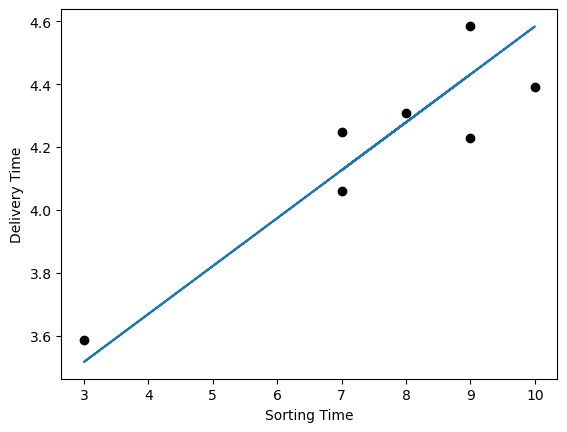

In [46]:
plt.scatter(x_test,y_test,color="black")
plt.plot(x_test,y_pred_test)
plt.xlabel("Sorting Time")
plt.ylabel("Delivery Time")
plt.show()

In [47]:
from sklearn.metrics import r2_score
score = r2_score(y_train,y_pred_train)
print("The accuracy of our model is {}%".format(round(score, 2) *100))

The accuracy of our model is 66.0%


In [48]:
from sklearn.metrics import mean_squared_error

mse =mean_squared_error(y_test,y_pred_test)
mse

0.018034884729133914

In [49]:
rmse=np.sqrt(mse)
rmse

0.13429402343043384